### Import Necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
from sklearn.inspection import permutation_importance
from scipy import stats
import math
import pickle


In [12]:
# Load the dataset

df = pd.read_excel('Machine Operating Details.xlsm', sheet_name='Consumptions')

### Data Preprocessing

In [13]:
# No.of Rows and columns

df.shape

(842, 22)

In [14]:
# Dataset Preview

df.head()

,Date,Knitting - D,Knitting - N,Bulk Dye - D,Bulk Dye - N,Sample Dye - D,Sample Dye - N,Dryers - D,Dryers - N,Presetting - D,...,Chillers - N,AHU - D,AHU - N,Compressor - D,Compressor - N,Luwa - D,Luwa - N,Electricity (kWh),Steam (kg),Total Water (Cu.m.)
0,2024-01-01,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,1105,-,-
1,2024-01-02,-,-,-,-,-,-,-,-,-,...,1,5,6,2,3,0,9,19118,50189,713
2,2024-01-15,36,30,-,38,2,-,6,-,-,...,1,5,4,2,2,3,3,18897,44268,437
3,2024-01-24,9,9,37,37,-,-,-,-,-,...,1,1,4,1,1,1,1,11195,84619,1064
4,2024-01-25,11,3,36,34,-,-,-,-,-,...,1,3,2,1,1,1,1,11593,85820,1023


In [15]:
# Checking for null values

df.isnull().sum()

Date                   0
Knitting - D           1
Knitting - N           0
Bulk Dye - D           0
Bulk Dye - N           0
Sample Dye - D         0
Sample Dye - N         0
Dryers - D             0
Dryers - N             0
Presetting - D         0
Presetting - N         0
Chillers - D           0
Chillers - N           0
AHU - D                0
AHU - N                0
Compressor - D         0
Compressor - N         0
Luwa - D               0
Luwa - N               0
Electricity (kWh)      0
Steam (kg)             0
Total Water (Cu.m.)    0
dtype: int64

In [16]:
# Checking for duplicate values

df.duplicated().sum()

np.int64(0)

In [17]:
# Data Cleaning
# Replace '-' with NaN

df.replace('-', np.nan, inplace=True)

,Date,Knitting - D,Knitting - N,Bulk Dye - D,Bulk Dye - N,Sample Dye - D,Sample Dye - N,Dryers - D,Dryers - N,Presetting - D,...,Chillers - N,AHU - D,AHU - N,Compressor - D,Compressor - N,Luwa - D,Luwa - N,Electricity (kWh),Steam (kg),Total Water (Cu.m.)
0,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1105,NaN,NaN
1,2024-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,5,6,2,3,0,9,19118,50189,713
2,2024-01-15,36,30,NaN,38,2,NaN,6,NaN,NaN,...,1,5,4,2,2,3,3,18897,44268,437
3,2024-01-24,9,9,37,37,NaN,NaN,NaN,NaN,NaN,...,1,1,4,1,1,1,1,11195,84619,1064
4,2024-01-25,11,3,36,34,NaN,NaN,NaN,NaN,NaN,...,1,3,2,1,1,1,1,11593,85820,1023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,2026-06-05,175,163,37,36,11,11,10,10,4,...,2,10,9,3,3,8,8,33099.31,72036,1044.54
838,2026-06-06,180,185,37,37,11,11,10,10,4,...,2,9,10,3,3,8,8,33300.08,75562,1109.04
839,2026-06-07,180,188,37,37,11,11,10,10,4,...,2,9,10,3,3,8,8,32677.83,73727,1068.58
840,2026-06-08,150,155,37,37,11,11,10,10,4,...,2,10,9,3,3,8,8,32179,78475,1125.16


In [18]:
#Then fill NaNs with 0

df.fillna(0, inplace=True)

,Date,Knitting - D,Knitting - N,Bulk Dye - D,Bulk Dye - N,Sample Dye - D,Sample Dye - N,Dryers - D,Dryers - N,Presetting - D,...,Chillers - N,AHU - D,AHU - N,Compressor - D,Compressor - N,Luwa - D,Luwa - N,Electricity (kWh),Steam (kg),Total Water (Cu.m.)
0,2024-01-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1105,0,0
1,2024-01-02,0,0,0,0,0,0,0,0,0,...,1,5,6,2,3,0,9,19118,50189,713
2,2024-01-15,36,30,0,38,2,0,6,0,0,...,1,5,4,2,2,3,3,18897,44268,437
3,2024-01-24,9,9,37,37,0,0,0,0,0,...,1,1,4,1,1,1,1,11195,84619,1064
4,2024-01-25,11,3,36,34,0,0,0,0,0,...,1,3,2,1,1,1,1,11593,85820,1023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,2026-06-05,175,163,37,36,11,11,10,10,4,...,2,10,9,3,3,8,8,33099.31,72036,1044.54
838,2026-06-06,180,185,37,37,11,11,10,10,4,...,2,9,10,3,3,8,8,33300.08,75562,1109.04
839,2026-06-07,180,188,37,37,11,11,10,10,4,...,2,9,10,3,3,8,8,32677.83,73727,1068.58
840,2026-06-08,150,155,37,37,11,11,10,10,4,...,2,10,9,3,3,8,8,32179,78475,1125.16


In [19]:
df.head()

,Date,Knitting - D,Knitting - N,Bulk Dye - D,Bulk Dye - N,Sample Dye - D,Sample Dye - N,Dryers - D,Dryers - N,Presetting - D,...,Chillers - N,AHU - D,AHU - N,Compressor - D,Compressor - N,Luwa - D,Luwa - N,Electricity (kWh),Steam (kg),Total Water (Cu.m.)
0,2024-01-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1105,0,0
1,2024-01-02,0,0,0,0,0,0,0,0,0,...,1,5,6,2,3,0,9,19118,50189,713
2,2024-01-15,36,30,0,38,2,0,6,0,0,...,1,5,4,2,2,3,3,18897,44268,437
3,2024-01-24,9,9,37,37,0,0,0,0,0,...,1,1,4,1,1,1,1,11195,84619,1064
4,2024-01-25,11,3,36,34,0,0,0,0,0,...,1,3,2,1,1,1,1,11593,85820,1023


In [20]:
df.isnull().sum()

Date                   0
Knitting - D           0
Knitting - N           0
Bulk Dye - D           0
Bulk Dye - N           0
Sample Dye - D         0
Sample Dye - N         0
Dryers - D             0
Dryers - N             0
Presetting - D         0
Presetting - N         0
Chillers - D           0
Chillers - N           0
AHU - D                0
AHU - N                0
Compressor - D         0
Compressor - N         0
Luwa - D               0
Luwa - N               0
Electricity (kWh)      0
Steam (kg)             0
Total Water (Cu.m.)    0
dtype: int64

In [21]:
# Drop unnecessary columns

columns_to_drop = [
    'Date', 'Steam (kg)',
    'Total Water (Cu.m.)'
]
df.drop(columns=columns_to_drop, inplace=True)

In [22]:
df.head()

,Knitting - D,Knitting - N,Bulk Dye - D,Bulk Dye - N,Sample Dye - D,Sample Dye - N,Dryers - D,Dryers - N,Presetting - D,Presetting - N,Chillers - D,Chillers - N,AHU - D,AHU - N,Compressor - D,Compressor - N,Luwa - D,Luwa - N,Electricity (kWh)
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1105
1,0,0,0,0,0,0,0,0,0,0,1,1,5,6,2,3,0,9,19118
2,36,30,0,38,2,0,6,0,0,0,1,1,5,4,2,2,3,3,18897
3,9,9,37,37,0,0,0,0,0,0,1,1,1,4,1,1,1,1,11195
4,11,3,36,34,0,0,0,0,0,0,1,1,3,2,1,1,1,1,11593


In [23]:
# Check the data types of each variable
print(df.dtypes)

Knitting - D         object
Knitting - N         object
Bulk Dye - D         object
Bulk Dye - N         object
Sample Dye - D       object
Sample Dye - N       object
Dryers - D           object
Dryers - N           object
Presetting - D       object
Presetting - N       object
Chillers - D         object
Chillers - N         object
AHU - D              object
AHU - N              object
Compressor - D       object
Compressor - N       object
Luwa - D             object
Luwa - N             object
Electricity (kWh)    object
dtype: object


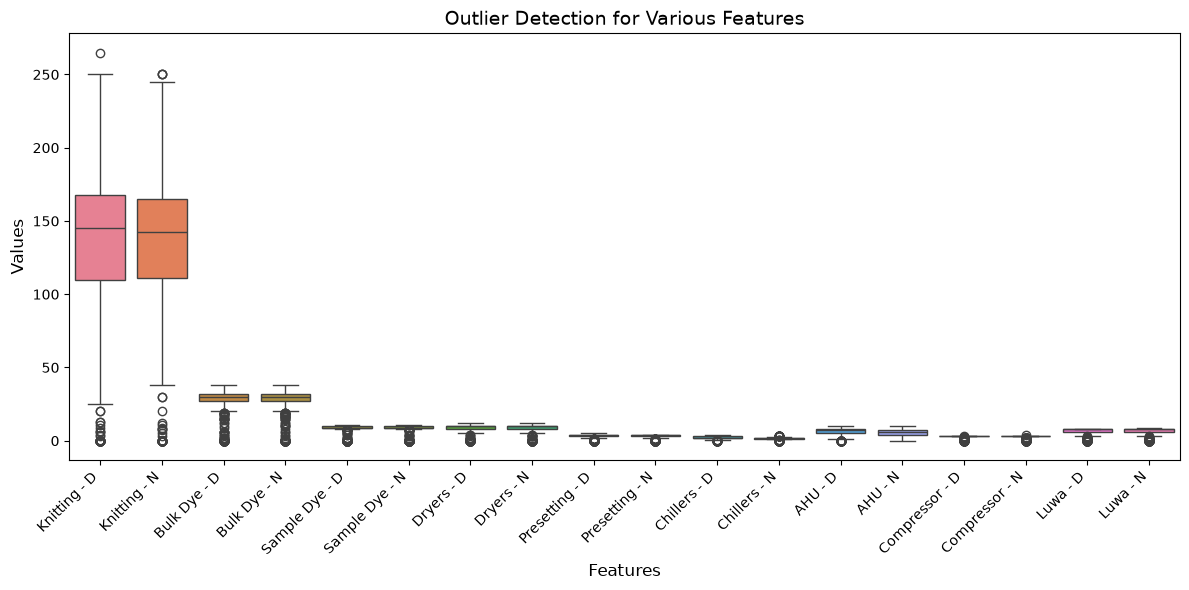

In [24]:
# Outlier Detection and Handling

columns_ind = df.iloc[:,:18]

plt.figure(figsize=(12, 6))
sns.boxplot(data=columns_ind)

# Add title and labels

plt.title("Outlier Detection for Various Features", fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels for better readability
plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)

# Show the plot

plt.tight_layout()
plt.show()

In [25]:
# Calculating IQR for each column
Q1 = columns_ind.quantile(0.25)
Q3 = columns_ind.quantile(0.75)
IQR = Q3 - Q1

# Identifying outliers
outliers = ((columns_ind < (Q1 - 1.5 * IQR)) | (columns_ind > (Q3 + 1.5 * IQR)))

# Count outliers for each column
outlier_counts = outliers.sum(axis=0)

print("Outlier counts in each column:")
print(outlier_counts)

Outlier counts in each column:
Knitting - D       87
Knitting - N       94
Bulk Dye - D      102
Bulk Dye - N      108
Sample Dye - D    130
Sample Dye - N    129
Dryers - D         94
Dryers - N         95
Presetting - D    110
Presetting - N    116
Chillers - D       46
Chillers - N      103
AHU - D            50
AHU - N             0
Compressor - D    177
Compressor - N    180
Luwa - D           91
Luwa - N           87
dtype: int64


In [26]:
# Replacing outliers with NaN (or any other strategy like median)
data_no_outliers = columns_ind.mask(outliers)

# Optionally, you can replace NaN values with the column median
data_no_outliers = data_no_outliers.fillna(columns_ind.median())

data_no_outliers

,Knitting - D,Knitting - N,Bulk Dye - D,Bulk Dye - N,Sample Dye - D,Sample Dye - N,Dryers - D,Dryers - N,Presetting - D,Presetting - N,Chillers - D,Chillers - N,AHU - D,AHU - N,Compressor - D,Compressor - N,Luwa - D,Luwa - N
0,145.0,142.5,30.0,30.0,9.0,9.0,10.0,10.0,4.0,4.0,2.0,2.0,7.0,0,3.0,3.0,8.0,8.0
1,145.0,142.5,30.0,30.0,9.0,9.0,10.0,10.0,4.0,4.0,1,1,5,6,3.0,3,8.0,9
2,36,142.5,30.0,38,9.0,9.0,6,10.0,4.0,4.0,1,1,5,4,3.0,3.0,3,3
3,145.0,142.5,37,37,9.0,9.0,10.0,10.0,4.0,4.0,1,1,1,4,3.0,3.0,8.0,8.0
4,145.0,142.5,36,34,9.0,9.0,10.0,10.0,4.0,4.0,1,1,3,2,3.0,3.0,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,175,163,37,36,11,11,10,10,4,4,3.5,2,10,9,3,3,8,8
838,180,185,37,37,11,11,10,10,4,4,3,2,9,10,3,3,8,8
839,180,188,37,37,11,11,10,10,4,4,3,2,9,10,3,3,8,8
840,150,155,37,37,11,11,10,10,4,4,3.5,2,10,9,3,3,8,8


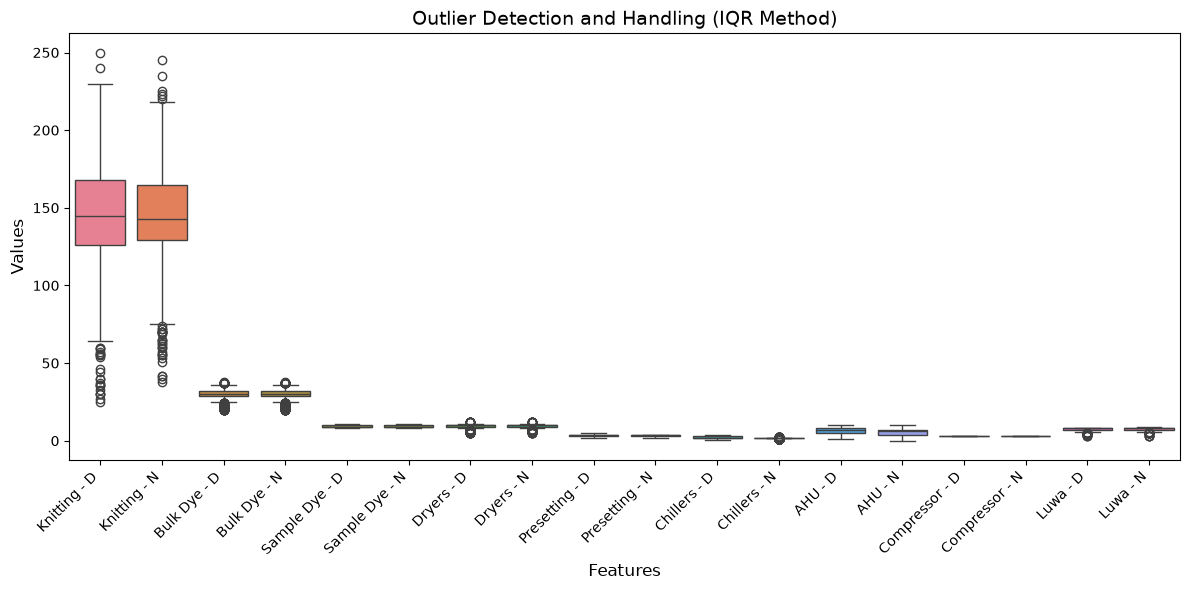

In [27]:
# Plotting Boxplot after handling outliers

plt.figure(figsize=(12, 6))
sns.boxplot(data=data_no_outliers)
plt.title("Outlier Detection and Handling (IQR Method)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.tight_layout()
plt.show()



In [28]:
data = pd.concat([data_no_outliers, df['Electricity (kWh)']], axis=1)

In [29]:
df.isnull().sum()

Knitting - D         0
Knitting - N         0
Bulk Dye - D         0
Bulk Dye - N         0
Sample Dye - D       0
Sample Dye - N       0
Dryers - D           0
Dryers - N           0
Presetting - D       0
Presetting - N       0
Chillers - D         0
Chillers - N         0
AHU - D              0
AHU - N              0
Compressor - D       0
Compressor - N       0
Luwa - D             0
Luwa - N             0
Electricity (kWh)    0
dtype: int64

In [30]:
# Check the data types of each variable
print(df.dtypes)

Knitting - D         object
Knitting - N         object
Bulk Dye - D         object
Bulk Dye - N         object
Sample Dye - D       object
Sample Dye - N       object
Dryers - D           object
Dryers - N           object
Presetting - D       object
Presetting - N       object
Chillers - D         object
Chillers - N         object
AHU - D              object
AHU - N              object
Compressor - D       object
Compressor - N       object
Luwa - D             object
Luwa - N             object
Electricity (kWh)    object
dtype: object


### Data Visualization

#### Correlation between Independant Variables

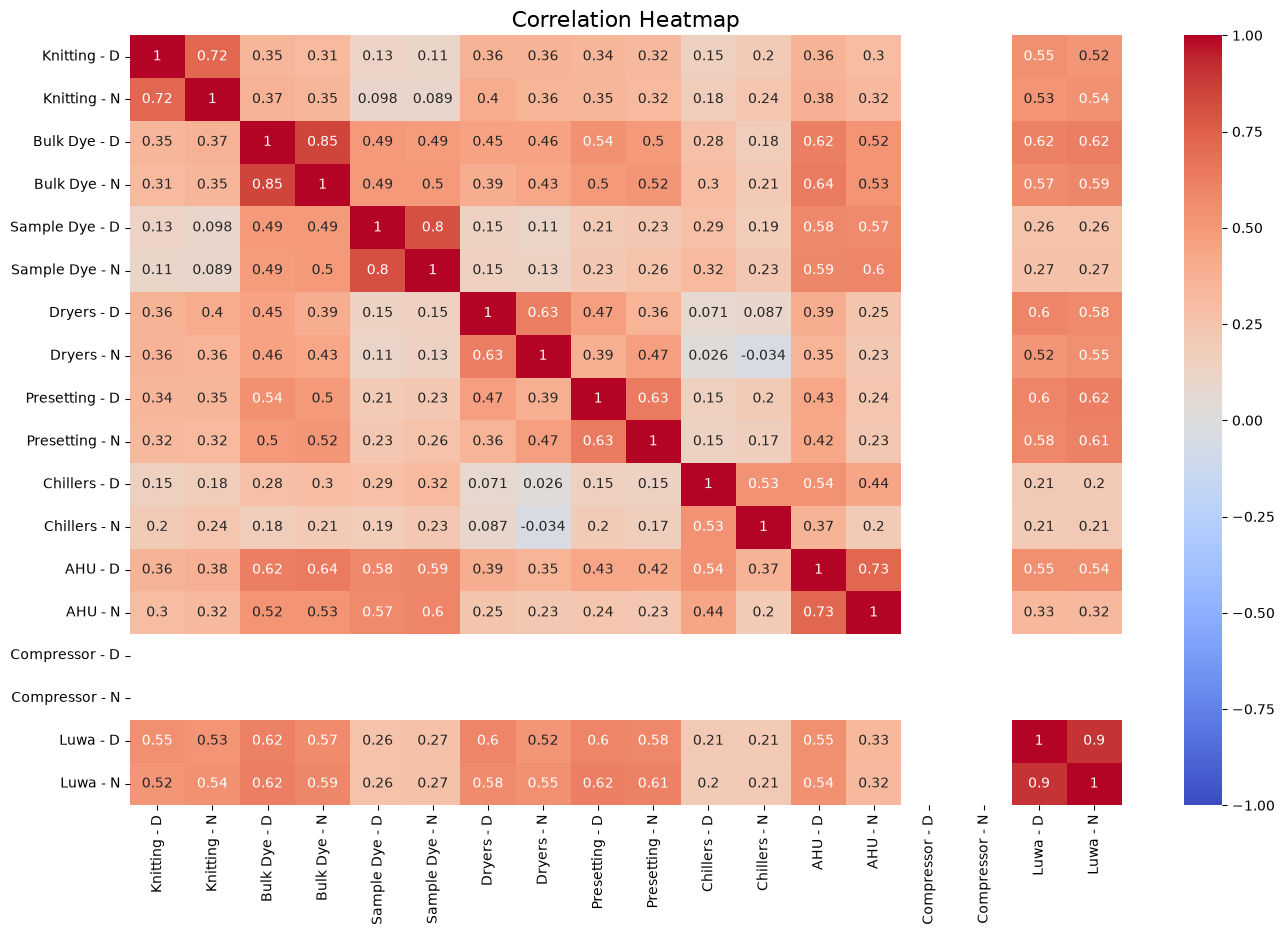

In [31]:
# Select the columns for the heatmap
columns_corr = [
    'Knitting - D', 'Knitting - N', 
    'Bulk Dye - D', 'Bulk Dye - N', 
    'Sample Dye - D', 'Sample Dye - N', 
    'Dryers - D', 'Dryers - N', 
    'Presetting - D', 'Presetting - N', 
    'Chillers - D', 'Chillers - N', 
    'AHU - D', 'AHU - N', 
    'Compressor - D', 'Compressor - N', 
    'Luwa - D', 'Luwa - N'
]

# Draw the heatmap

plt.figure(figsize=(16, 10))
sns.heatmap(data[columns_corr].corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

#### Correlation between Independant Variables & Electricity(kWh) 

C:\Users\SayuriH\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\SayuriH\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Figure size 1200x800 with 0 Axes>

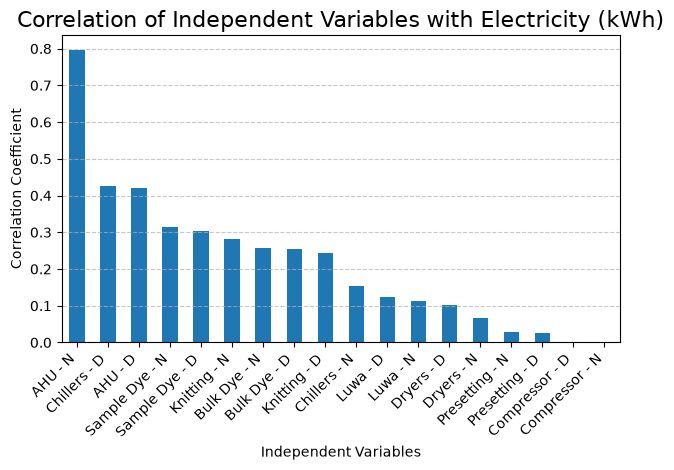

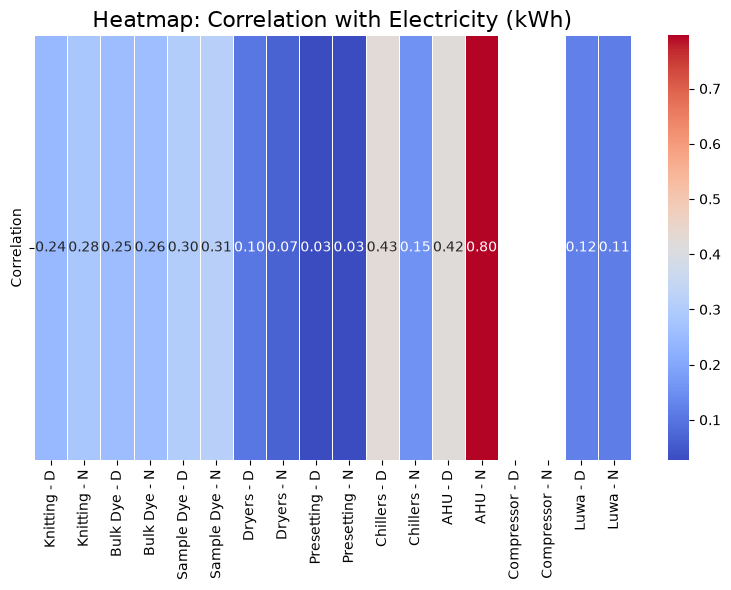

In [32]:
dependent_variable_corr = 'Electricity (kWh)'

# Calculate correlation coefficients
correlations = {
    column: data[column].corr(data[dependent_variable_corr]) for column in columns_corr
}

# Convert to DataFrame for visualization
correlation_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])

# Plot the correlation as a bar chart
plt.figure(figsize=(12, 8))
correlation_df.sort_values(by='Correlation', ascending=False).plot(kind='bar', legend=False)
plt.title(f"Correlation of Independent Variables with {dependent_variable_corr}", fontsize=16)
plt.ylabel("Correlation Coefficient")
plt.xlabel("Independent Variables")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Optionally, as a heatmap:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_df.T, annot=True, cmap="coolwarm", cbar=True, fmt=".2f", linewidths=0.5)
plt.title(f"Heatmap: Correlation with {dependent_variable_corr}", fontsize=16)
plt.tight_layout()
plt.show()

#### Distribution of each Independant Variable

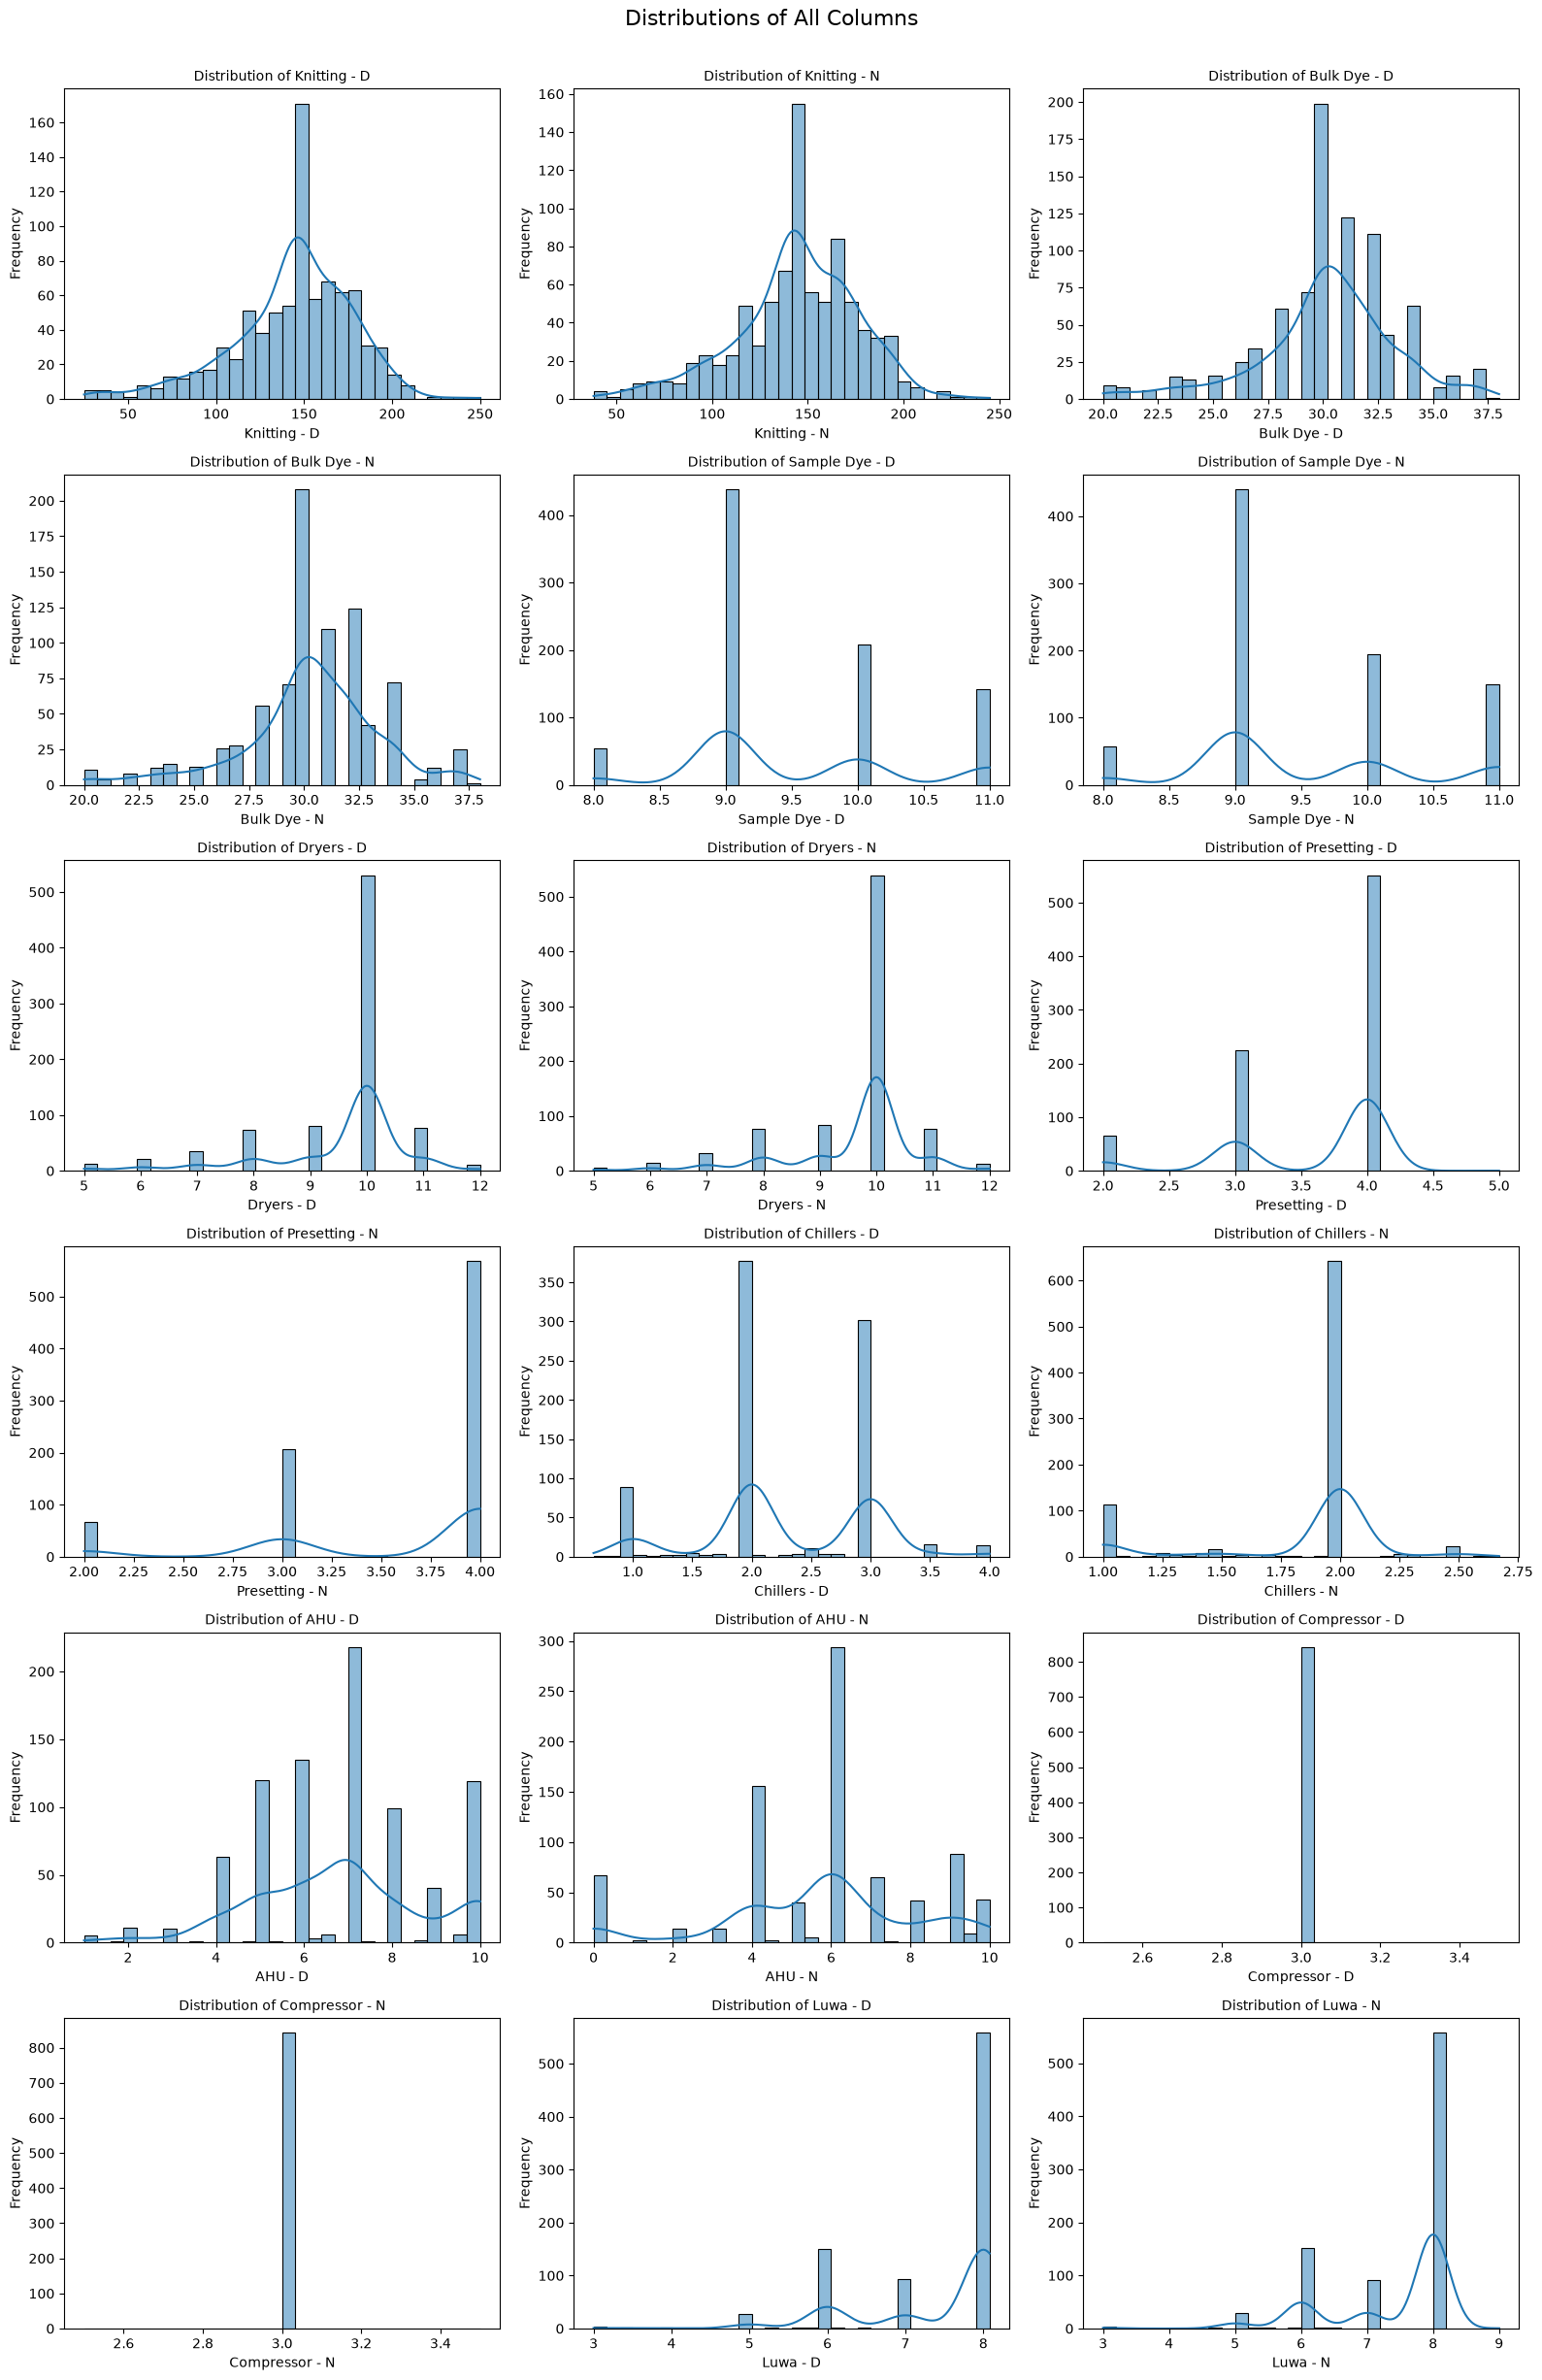

In [34]:
columns = [
    'Knitting - D', 'Knitting - N', 
    'Bulk Dye - D', 'Bulk Dye - N', 
    'Sample Dye - D', 'Sample Dye - N', 
    'Dryers - D', 'Dryers - N', 
    'Presetting - D', 'Presetting - N', 
    'Chillers - D', 'Chillers - N', 
    'AHU - D', 'AHU - N', 
    'Compressor - D', 'Compressor - N', 
    'Luwa - D', 'Luwa - N'
]

# Calculate the grid size for subplots
n_columns = 3  # Number of histograms per row
n_rows = math.ceil(len(columns) / n_columns)  # Number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, n_rows * 4))
axes = axes.flatten()  # Flatten axes array for easy indexing

# Plot each histogram
for i, column in enumerate(columns):
    sns.histplot(data[column], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {column}", fontsize=10)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

# Remove any unused subplots
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.suptitle("Distributions of All Columns", fontsize=16, y=1.02)
plt.show()

#### Trends for all Independant Variables

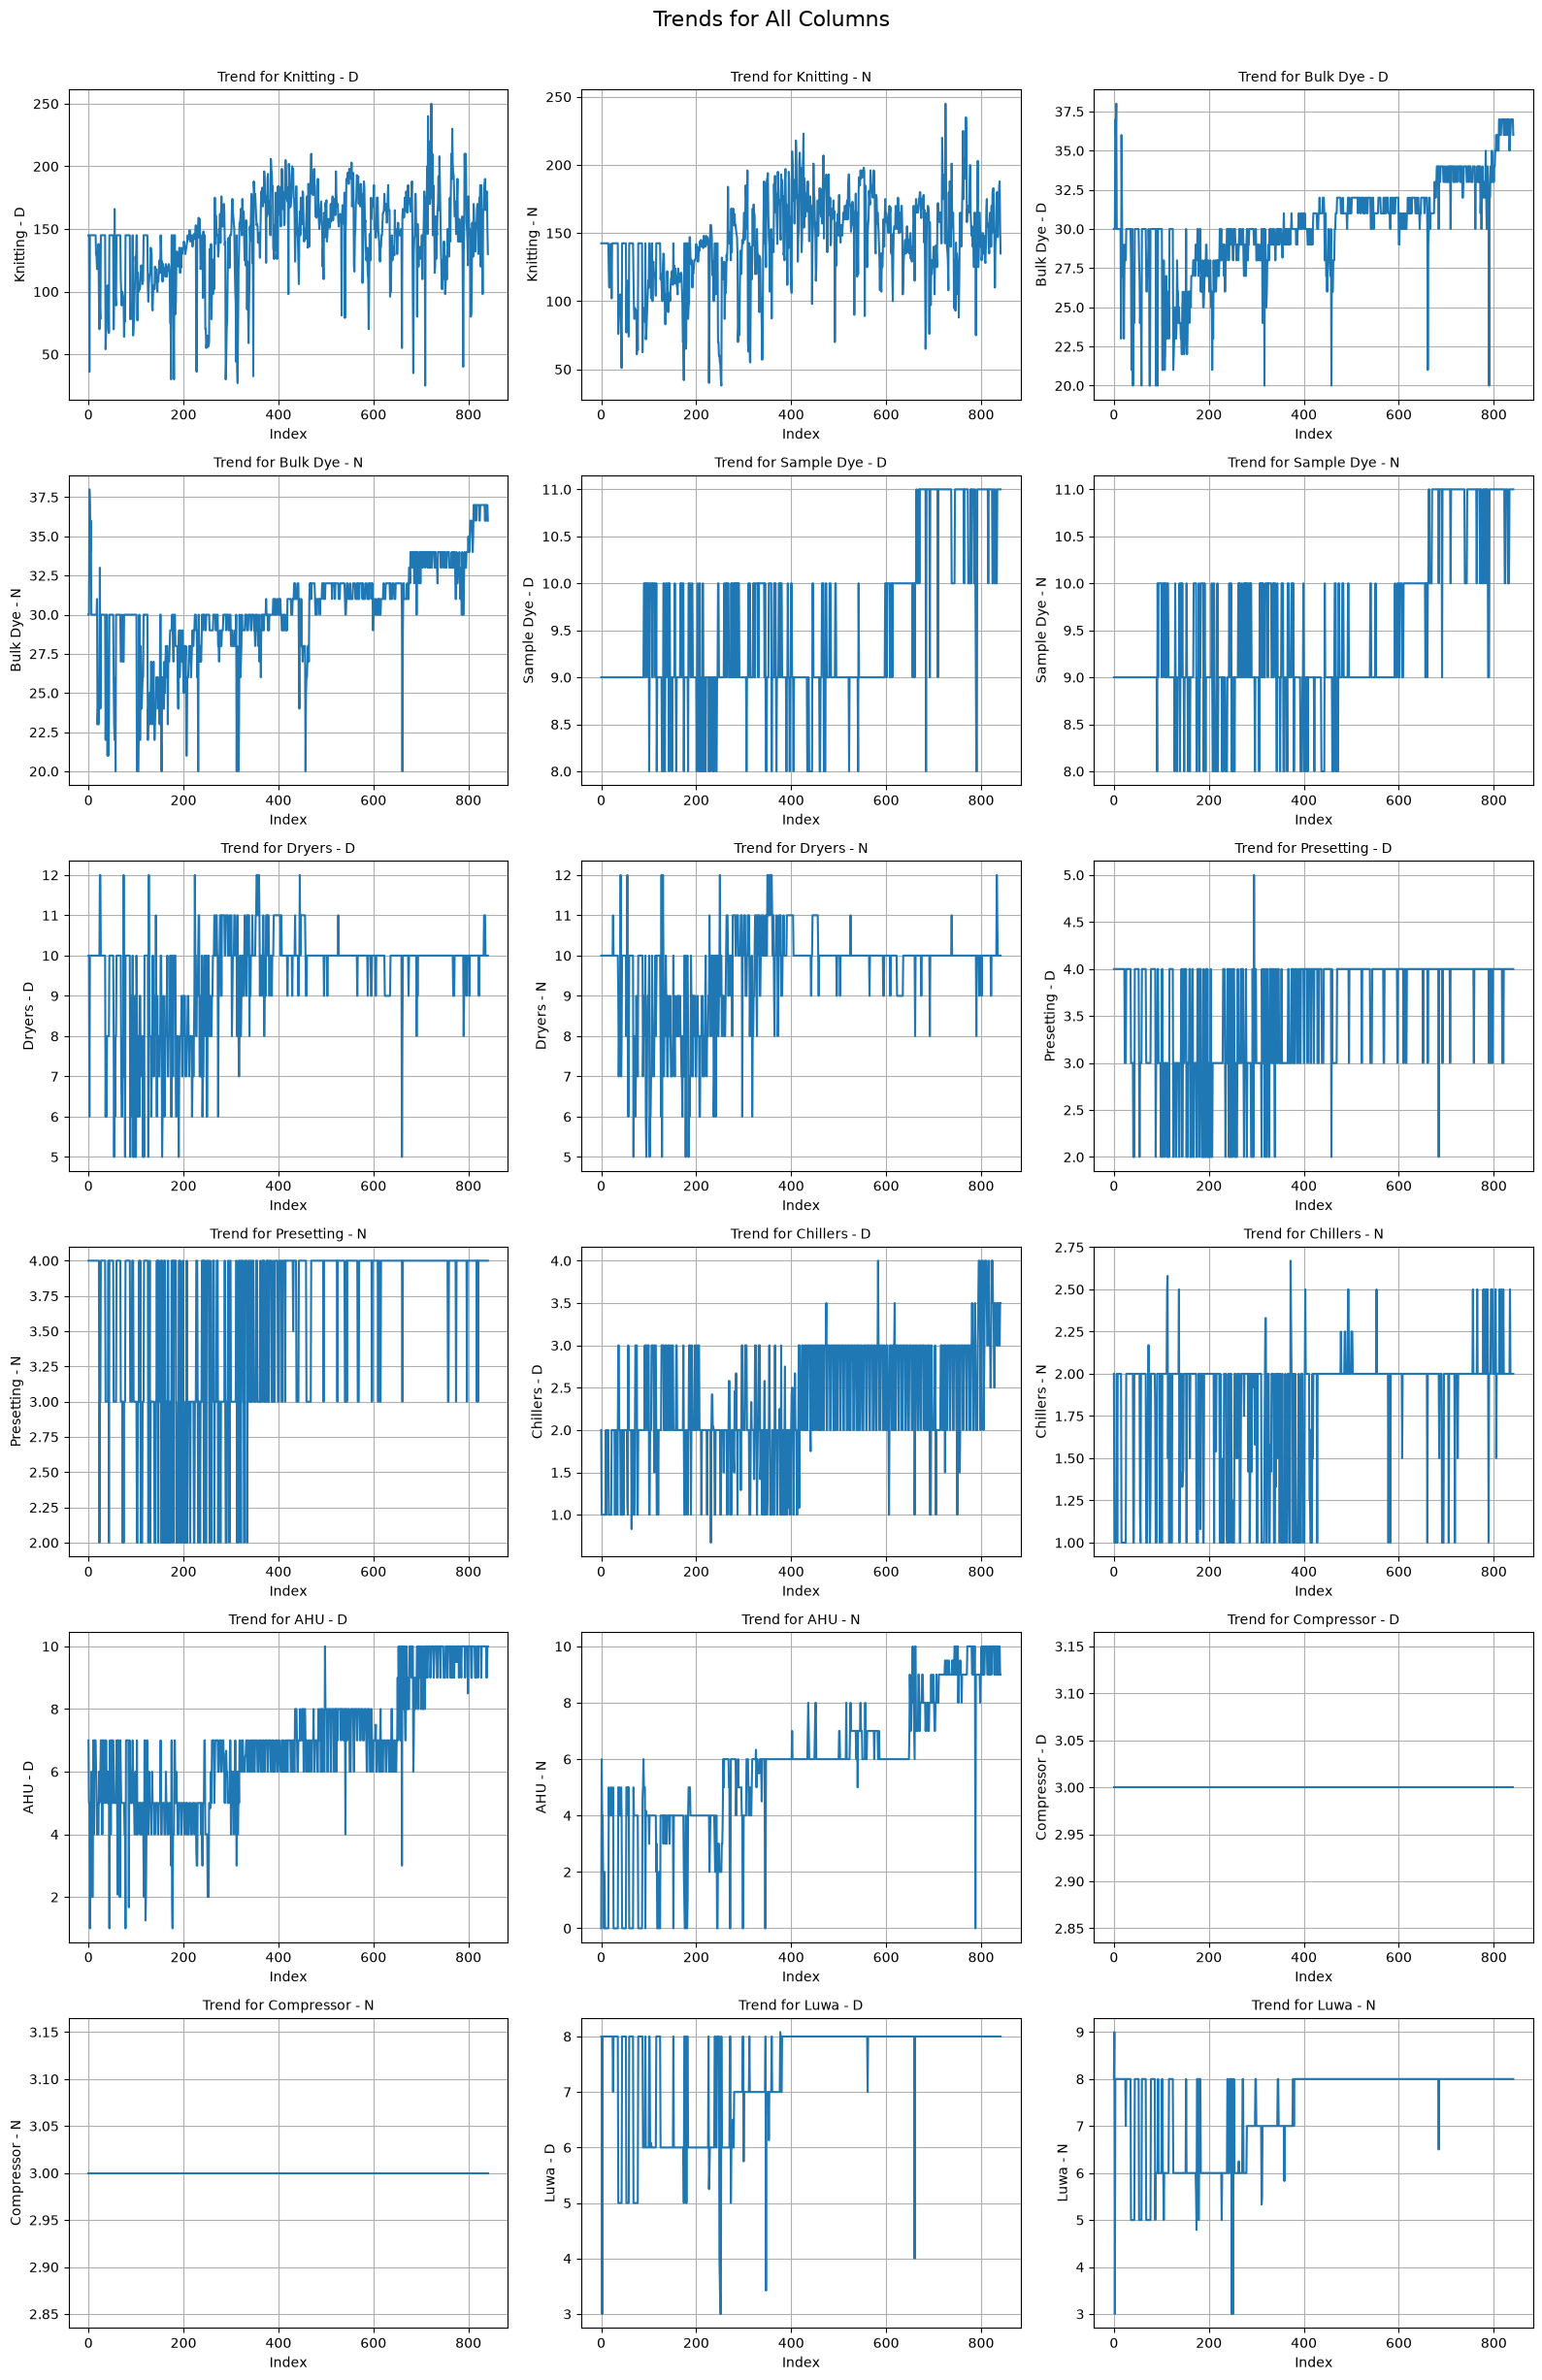

In [35]:
# Calculate the grid size for subplots
n_columns = 3  # Number of plots per row
n_rows = math.ceil(len(columns) / n_columns)  # Number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, n_rows * 4))
axes = axes.flatten()  # Flatten axes array for easy indexing

# Plot each trend
for i, column in enumerate(columns):
    axes[i].plot(data[column])
    axes[i].set_title(f"Trend for {column}", fontsize=10)
    axes[i].set_xlabel("Index")
    axes[i].set_ylabel(column)
    axes[i].grid(True)

# Remove any unused subplots
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.suptitle("Trends for All Columns", fontsize=16, y=1.02)
plt.show()



#### Scatter Plots - Independant Variables vs Dependant Variable

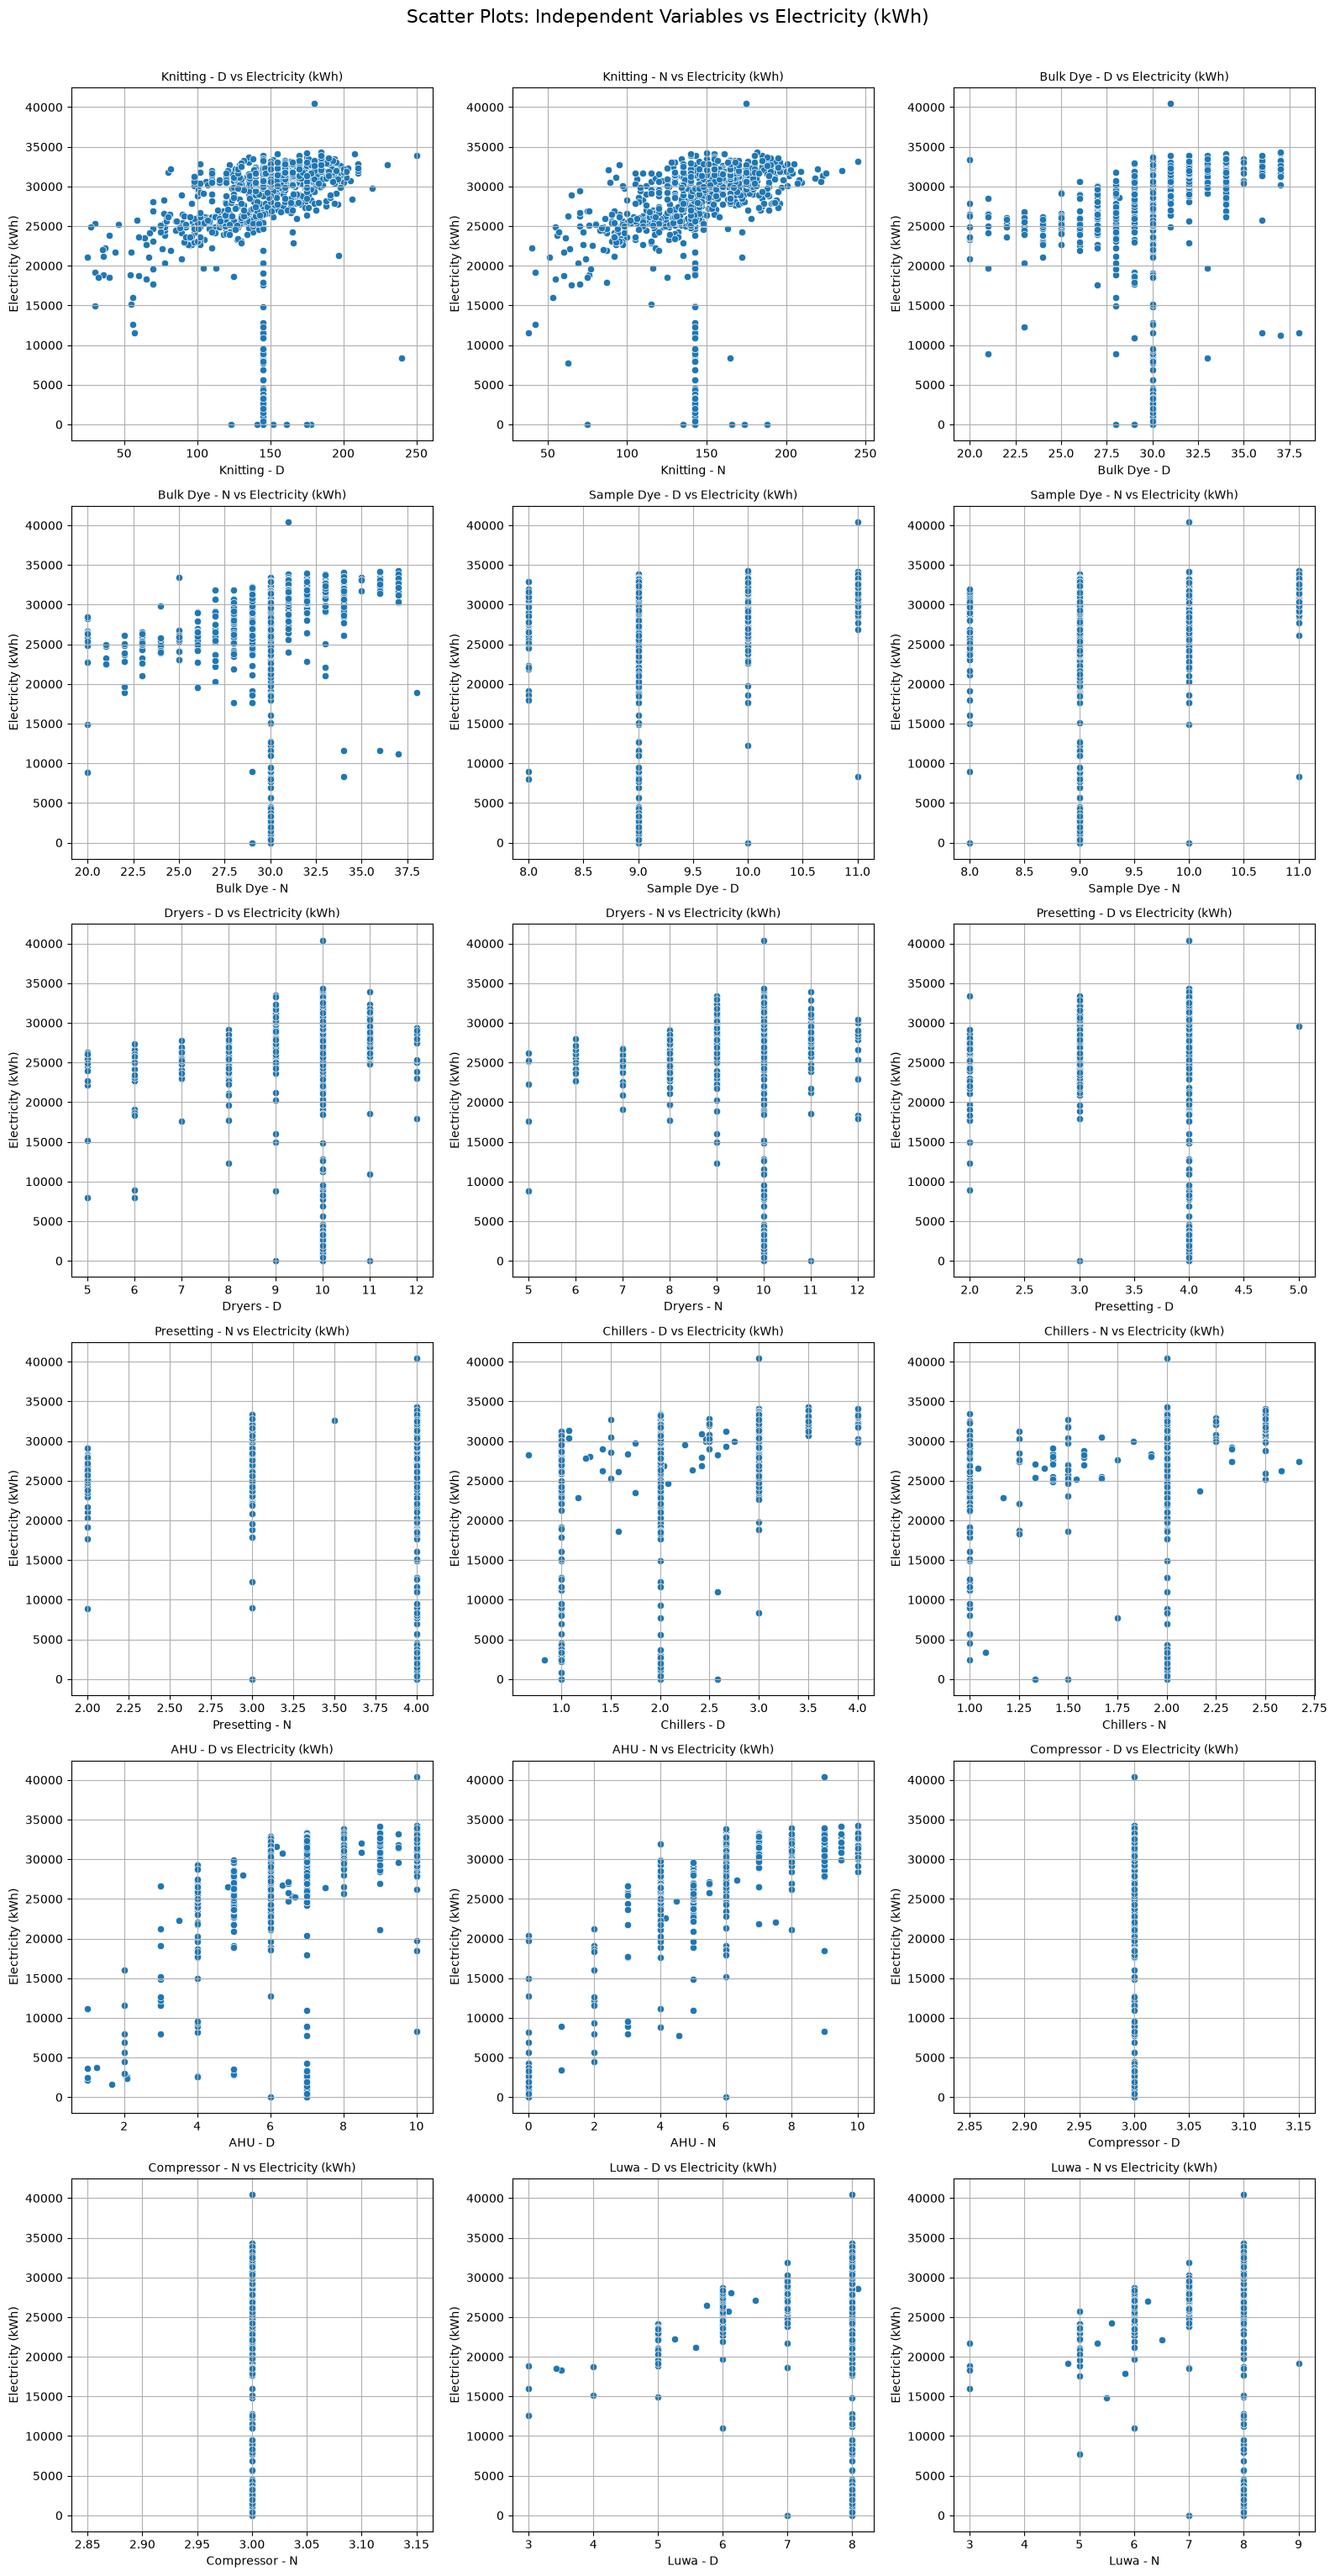

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Define independent variables
independent_columns = [
    'Knitting - D', 'Knitting - N', 
    'Bulk Dye - D', 'Bulk Dye - N', 
    'Sample Dye - D', 'Sample Dye - N', 
    'Dryers - D', 'Dryers - N', 
    'Presetting - D', 'Presetting - N', 
    'Chillers - D', 'Chillers - N', 
    'AHU - D', 'AHU - N', 
    'Compressor - D', 'Compressor - N', 
    'Luwa - D', 'Luwa - N'
]

dependent_variable = 'Electricity (kWh)'  # Dependent variable

# Calculate the grid size for subplots
n_columns = 3  # Number of scatter plots per row
n_rows = math.ceil(len(independent_columns) / n_columns)  # Number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, n_rows * 5))
axes = axes.flatten()  # Flatten axes array for easy indexing

# Plot each scatter plot
for i, column in enumerate(independent_columns):
    sns.scatterplot(x=column, y=dependent_variable, data=data, ax=axes[i])
    axes[i].set_title(f"{column} vs {dependent_variable}", fontsize=10)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel(dependent_variable)
    axes[i].grid(True)

# Remove any unused subplots
for j in range(len(independent_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.suptitle(f"Scatter Plots: Independent Variables vs {dependent_variable}", fontsize=16, y=1.02)
plt.show()


#### Mean Values of Independant Variables

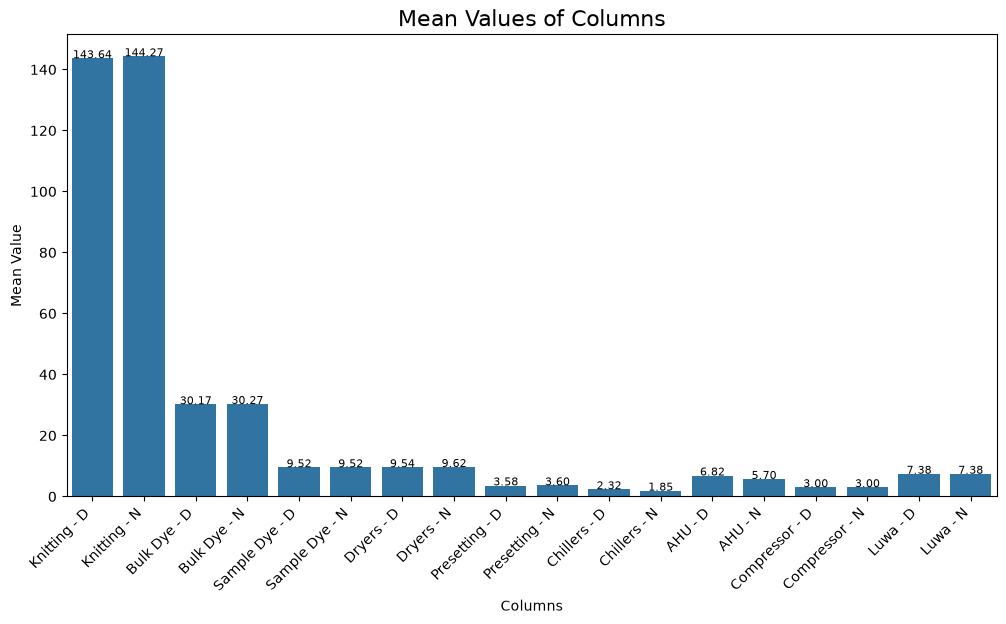

In [37]:
mean_values = data[columns].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=mean_values.index, y=mean_values.values)

# Add data labels
for i, value in enumerate(mean_values.values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', fontsize=8)  # Adjust offset and format as needed

# Add title and labels
plt.title("Mean Values of Columns", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Columns")
plt.ylabel("Mean Value")
plt.show()

### Feature and Target Selection

In [38]:
# Select features and target variable
features = data[['Knitting - D', 'Knitting - N', 'Bulk Dye - D', 'Bulk Dye - N', 
    'Sample Dye - D', 'Sample Dye - N', 'Dryers - D', 'Dryers - N', 
    'Presetting - D', 'Presetting - N', 'Chillers - D', 'Chillers - N', 
    'AHU - D', 'AHU - N', 'Compressor - D', 'Compressor - N', 'Luwa - D', 'Luwa - N']]
target = data['Electricity (kWh)']

In [39]:
# Convert features and target to numeric to handle any remaining string issues
features = features.apply(pd.to_numeric)
target = pd.to_numeric(target)

### Train - Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

### Models

#### Gradient Boosting Regression

In [41]:
# Gradient Boosting Regression
gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [42]:
gbr_cv_scores = cross_val_score(gbr_model, X_train, y_train, cv=5, scoring='r2')
print("Gradient Boosting Cross-validated R² scores:", gbr_cv_scores)
print("Gradient Boosting Mean Cross-validated R² score:", gbr_cv_scores.mean())

gbr_y_pred = gbr_model.predict(X_test)
print("Gradient Boosting MAE:", mean_absolute_error(y_test, gbr_y_pred))
print("Gradient Boosting RMSE:", math.sqrt(mean_squared_error(y_test, gbr_y_pred)))
print("Gradient Boosting R²:", r2_score(y_test, gbr_y_pred))

Gradient Boosting Cross-validated R² scores: [0.80186208 0.75447199 0.89307382 0.8222616  0.81394374]
Gradient Boosting Mean Cross-validated R² score: 0.8171226470687737
Gradient Boosting MAE: 1437.4724637461002
Gradient Boosting RMSE: 2470.7901606805694
Gradient Boosting R²: 0.931446129960331


#### Decision Tree Regression

In [43]:
# Decision Tree Regression

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [44]:
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='r2')
print("Decision Tree Regression Cross-validated R² scores:", dt_cv_scores)
print("Decision Tree Regression Mean Cross-validated R² score:", dt_cv_scores.mean())

dt_y_pred = dt_model.predict(X_test)
print("Decision Tree Regression MAE:", mean_absolute_error(y_test, dt_y_pred))
print("Decision Tree Regression RMSE:", math.sqrt(mean_squared_error(y_test, dt_y_pred)))
print("Decision Tree Regression R²:", r2_score(y_test, dt_y_pred))

Decision Tree Regression Cross-validated R² scores: [0.73050313 0.73689194 0.8535978  0.78918849 0.78564131]
Decision Tree Regression Mean Cross-validated R² score: 0.7791645338786759
Decision Tree Regression MAE: 1863.5023981671252
Decision Tree Regression RMSE: 3941.893477565011
Decision Tree Regression R²: 0.8255102105385277


#### Random Forest Model Training with Hyperparameter Tuning

In [46]:
param_grid = {
    'n_estimators': [100, 200, 300],  # Adequate number of trees for stable performance
    'max_depth': [10, 15, 20],  # Allow deeper trees but not excessive depth
    'min_samples_split': [5, 10],  # Balanced splitting to prevent overfitting
    'min_samples_leaf': [2, 4],  # Smaller leaf size to preserve predictive performance
    'max_features': ['sqrt', 'log2', None]  # Allow broader feature selection for better predictions
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=50,  # Enough iterations to explore the parameter space
    cv=5,  # Cross-validation to ensure model generalization
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the random search model

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [2, 4], 'min_samples_split': [5, 10], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

In [48]:
# Use the best model found
best_model = random_search.best_estimator_

# Cross-validation for better accuracy assessment
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print("Cross-validated R² scores:", cv_scores)
print("Mean Cross-validated R² score:", cv_scores.mean())

# Predict on the test set
y_pred = best_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned Mean Absolute Error (MAE):", mae)
print("Tuned Root Mean Squared Error (RMSE):", rmse)
print("Tuned R² Score:", r2)

Cross-validated R² scores: [0.8156694  0.81535613 0.90869942 0.83372463 0.8642688 ]
Mean Cross-validated R² score: 0.8475436750602487
Tuned Mean Absolute Error (MAE): 1229.0680981847113
Tuned Root Mean Squared Error (RMSE): 1680.2866087254379
Tuned R² Score: 0.9682950565491855


#### Extra Trees Regression

In [49]:
# Extra Trees Regression

etr_model = ExtraTreesRegressor(n_estimators=100, random_state=42)

# Fit the Extra Trees model

etr_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split ind

In [50]:
etr_cv_scores = cross_val_score(etr_model, X_train, y_train, cv=5, scoring='r2')
print("Extra Trees Regression Cross-validated R² scores:", etr_cv_scores)
print("Extra Trees Regression Mean Cross-validated R² score:", etr_cv_scores.mean())

etr_y_pred = etr_model.predict(X_test)
print("Extra Trees Regression MAE:", mean_absolute_error(y_test, etr_y_pred))
print("Extra Trees Regression RMSE:", math.sqrt(mean_squared_error(y_test, etr_y_pred)))
print("Extra Trees Regression R²:", r2_score(y_test, etr_y_pred))

Extra Trees Regression Cross-validated R² scores: [0.78748239 0.80778197 0.87446526 0.83398353 0.82677139]
Extra Trees Regression Mean Cross-validated R² score: 0.826096909740299
Extra Trees Regression MAE: 1330.397450627959
Extra Trees Regression RMSE: 2416.3280673883673
Extra Trees Regression R²: 0.9344350027116689


#### Stacked Regression

In [51]:
# Ensemble model: Stacking with Extra Trees and Gradient Boosting
stacked_model = StackingRegressor(
    estimators=[
        ('et', etr_model),
        ('gb', gbr_model),
        ('dt', dt_model)
    ],
    final_estimator=Ridge(alpha=1.0)  # Ridge Regression as the meta-learner
)

stacked_model.fit(X_train, y_train)
stacked_y_pred = stacked_model.predict(X_test)
print("Stacked Model MAE:", mean_absolute_error(y_test, stacked_y_pred))
print("Stacked Model RMSE:", math.sqrt(mean_squared_error(y_test, stacked_y_pred)))
print("Stacked Model R²:", r2_score(y_test, stacked_y_pred))

Stacked Model MAE: 1336.6173472318874
Stacked Model RMSE: 2288.3128519296606
Stacked Model R²: 0.9411981418697684


### Selected Model Evaluation

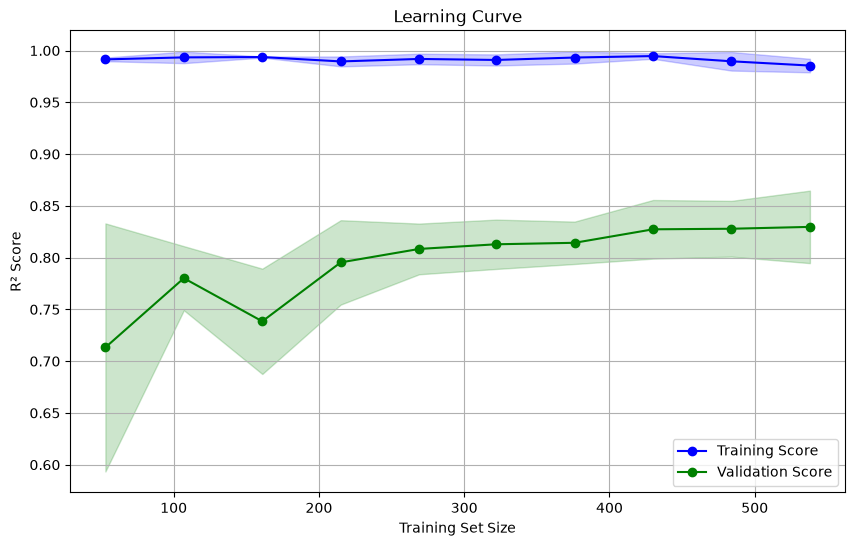

In [52]:
# Generate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    estimator=stacked_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='r2',  # R² score
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

# Calculate mean and standard deviation for training and validation scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.plot(train_sizes, val_mean, label="Validation Score", color="green", marker='o')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="green")

# Plot settings
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend(loc="best")
plt.grid()
plt.show()

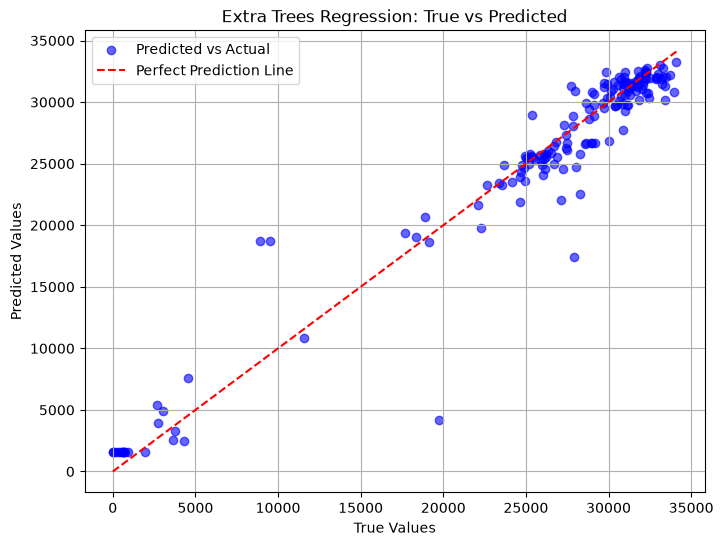

In [53]:
# Plot True vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, stacked_y_pred, alpha=0.6, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Extra Trees Regression: True vs Predicted')
plt.legend()
plt.grid()
plt.show()

Feature Importances (Averaged Across Base Models):
                Extra Trees  Gradient Boosting  Decision Tree  \
AHU - N            0.636502           0.728690       0.763158   
Luwa - N           0.051288           0.061106       0.114186   
AHU - D            0.058831           0.027514       0.060260   
Knitting - D       0.029408           0.033532       0.030741   
Bulk Dye - D       0.025866           0.049884       0.008826   
Knitting - N       0.025886           0.040405       0.004477   
Bulk Dye - N       0.033231           0.013573       0.000000   
Luwa - D           0.036570           0.007975       0.000000   
Chillers - D       0.018809           0.016702       0.000013   
Presetting - D     0.016290           0.004030       0.004371   
Presetting - N     0.007580           0.004033       0.011593   
Chillers - N       0.016301           0.005278       0.000150   
Sample Dye - N     0.017000           0.002104       0.000000   
Dryers - N         0.011134           0

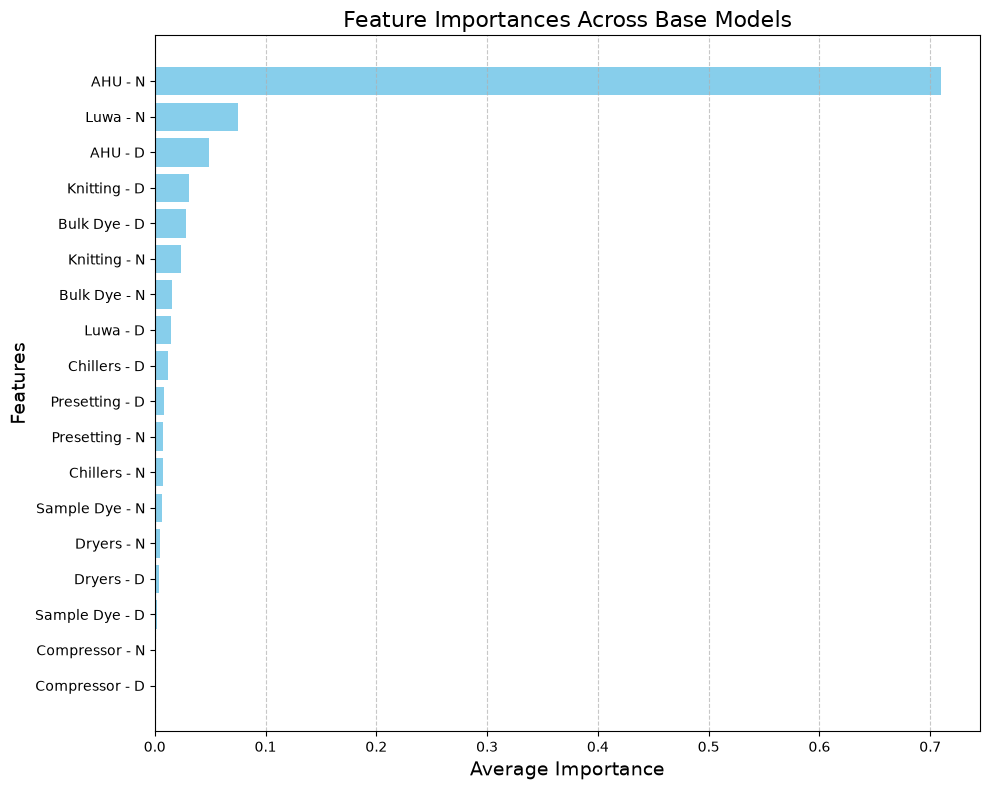

In [55]:
# Extract feature names
feature_names = X_train.columns

# Initialize a DataFrame to store feature importances
feature_importances = pd.DataFrame(index=feature_names)

# 1. Feature importance from Extra Trees
if hasattr(etr_model, 'feature_importances_'):
    feature_importances['Extra Trees'] = etr_model.feature_importances_
else:
    print("Extra Trees model does not provide feature importances.")

# 2. Feature importance from Gradient Boosting
if hasattr(gbr_model, 'feature_importances_'):
    feature_importances['Gradient Boosting'] = gbr_model.feature_importances_
else:
    print("Gradient Boosting model does not provide feature importances.")

# 3. Feature importance from Decision Tree
if hasattr(dt_model, 'feature_importances_'):
    feature_importances['Decision Tree'] = dt_model.feature_importances_
else:
    print("Decision Tree model does not provide feature importances.")

# Average the feature importances across all base models
feature_importances['Average Importance'] = feature_importances.mean(axis=1)

# Sort by average importance
feature_importances = feature_importances.sort_values(by='Average Importance', ascending=False)

# Display feature importances
print("Feature Importances (Averaged Across Base Models):")
print(feature_importances)

# 4. Coefficients from Ridge Regression (meta-learner)
if hasattr(stacked_model.final_estimator_, 'coef_'):
    ridge_coefs = stacked_model.final_estimator_.coef_
    print("\nMeta-Learner Ridge Regression Coefficients:")
    for i, coef in enumerate(ridge_coefs):
        print(f"Base Model {i+1} Coefficient: {coef:.4f}")
else:
    print("Meta-learner does not support coefficients.")

# Plot Inverse Histogram
plt.figure(figsize=(10, 8))
plt.barh(feature_importances.index, feature_importances['Average Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert the Y-axis to show the most important features at the top
plt.xlabel('Average Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.title('Feature Importances Across Base Models', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Prediction Test

In [56]:
# Define new input data as a dictionary
# Replace these values with the new inputs you want to test

new_data = {
    'Knitting - D': [174], 
    'Knitting - N': [120], 
    'Bulk Dye - D': [28], 
    'Bulk Dye - N': [29], 
    'Sample Dye - D': [9], 
    'Sample Dye - N': [9], 
    'Dryers - D': [9], 
    'Dryers - N': [11], 
    'Presetting - D': [3], 
    'Presetting - N': [4], 
    'Chillers - D': [3], 
    'Chillers - N': [2], 
    'AHU - D': [7], 
    'AHU - N': [6], 
    'Compressor - D': [3], 
    'Compressor - N': [3], 
    'Luwa - D': [7], 
    'Luwa - N': [7]
}

# Convert the dictionary to a DataFrame
new_input = pd.DataFrame(new_data)

# Predict using the best model
predicted_consumption = stacked_model.predict(new_input)

# Display the predicted result
print("Predicted Electricity Consumption (kWh) for new input:", predicted_consumption[0])

Predicted Electricity Consumption (kWh) for new input: 27969.139226641837


In [57]:
with open('./electricity_pkl.sav', 'wb') as file:
    pickle.dump(stacked_model, file)